In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

# Load State-wise Time Series Data directly from the source
# This CSV contains daily cumulative numbers for every state in India
url = 'https://data.covid19india.org/csv/latest/states.csv'

try:
    df = pd.read_csv(url)
    print("India State-wise Data loaded successfully!")
except Exception as e:
    print(f"Error loading data: {e}")

# Data Cleaning
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
print(f"Dataset Shape: {df.shape}")
df.tail()

India State-wise Data loaded successfully!
Dataset Shape: (21675, 7)


,Date,State,Confirmed,Recovered,Deceased,Other,Tested
21670,2021-10-31,Tripura,84468,83466,813,63,1983127.0
21671,2021-10-31,India,34285612,33661339,458470,13197,609201294.0
21672,2021-10-31,Uttar Pradesh,1710158,1687151,22900,0,83635222.0
21673,2021-10-31,Uttarakhand,343896,330195,7400,6150,7781148.0
21674,2021-10-31,West Bengal,1592908,1565471,19141,0,19228303.0


Top 5 States by Confirmed Cases (as of 2021-10-31):
                State  Confirmed  Active  Deceased
21657     Maharashtra    6611078   20277    140216
21654          Kerala    4968657   79795     31681
21653       Karnataka    2988333    8673     38082
21669      Tamil Nadu    2702623   11492     36116
21639  Andhra Pradesh    2066450    4355     14373


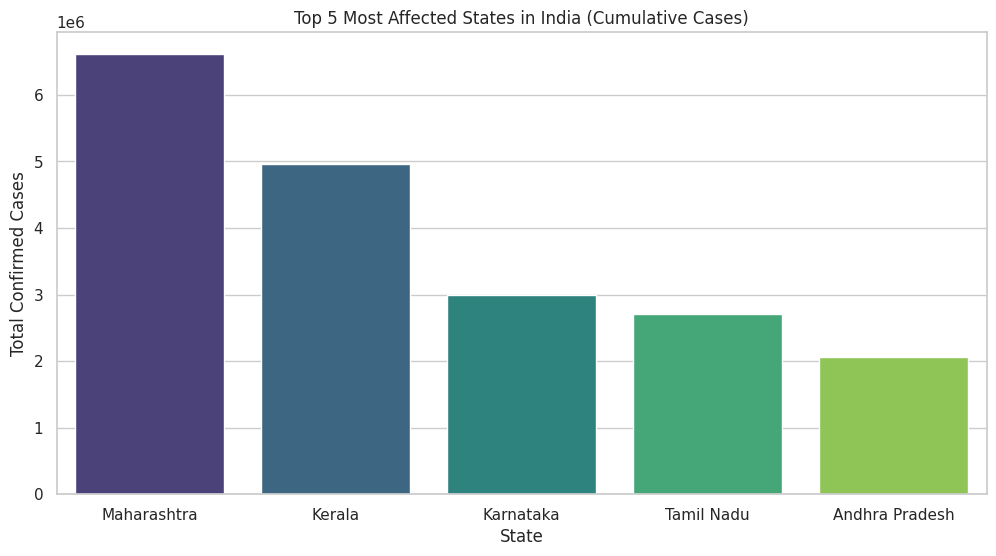

In [7]:
# Feature Engineering: Calculate Active Cases
# Active = Confirmed - Recovered - Deceased
df['Active'] = df['Confirmed'] - df['Recovered'] - df['Deceased']

# Get the latest date in the dataset
latest_date = df['Date'].max()
latest_data = df[df['Date'] == latest_date]

# Sort to find Top 5 worst affected states (excluding 'India' total row)
top_states = latest_data[latest_data['State'] != 'India'].sort_values(by='Confirmed', ascending=False).head(5)

print(f"Top 5 States by Confirmed Cases (as of {latest_date.date()}):")
print(top_states[['State', 'Confirmed', 'Active', 'Deceased']])

# Visualization: Bar Chart of Top 5 States
plt.figure(figsize=(12, 6))
sns.barplot(data=top_states, x='State', y='Confirmed', hue='State', palette='viridis', legend=False)
plt.title(f'Top 5 Most Affected States in India (Cumulative Cases)')
plt.ylabel('Total Confirmed Cases')
plt.xlabel('State')
plt.show()

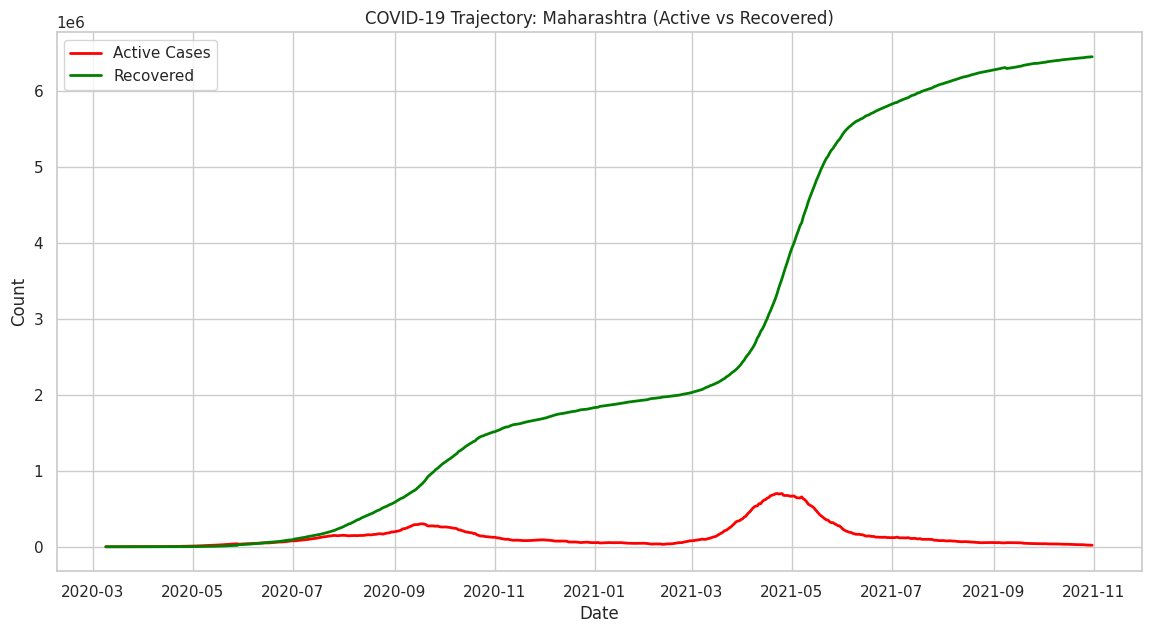

In [5]:
# User Input: Choose a state to "dig" into
target_state = 'Maharashtra'  # Change this to 'Delhi', 'Karnataka', etc.

state_df = df[df['State'] == target_state].copy()

# Plotting the Trend for the Target State
plt.figure(figsize=(14, 7))
plt.plot(state_df['Date'], state_df['Active'], color='red', linewidth=2, label='Active Cases')
plt.plot(state_df['Date'], state_df['Recovered'], color='green', linewidth=2, label='Recovered')

plt.title(f'COVID-19 Trajectory: {target_state} (Active vs Recovered)')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


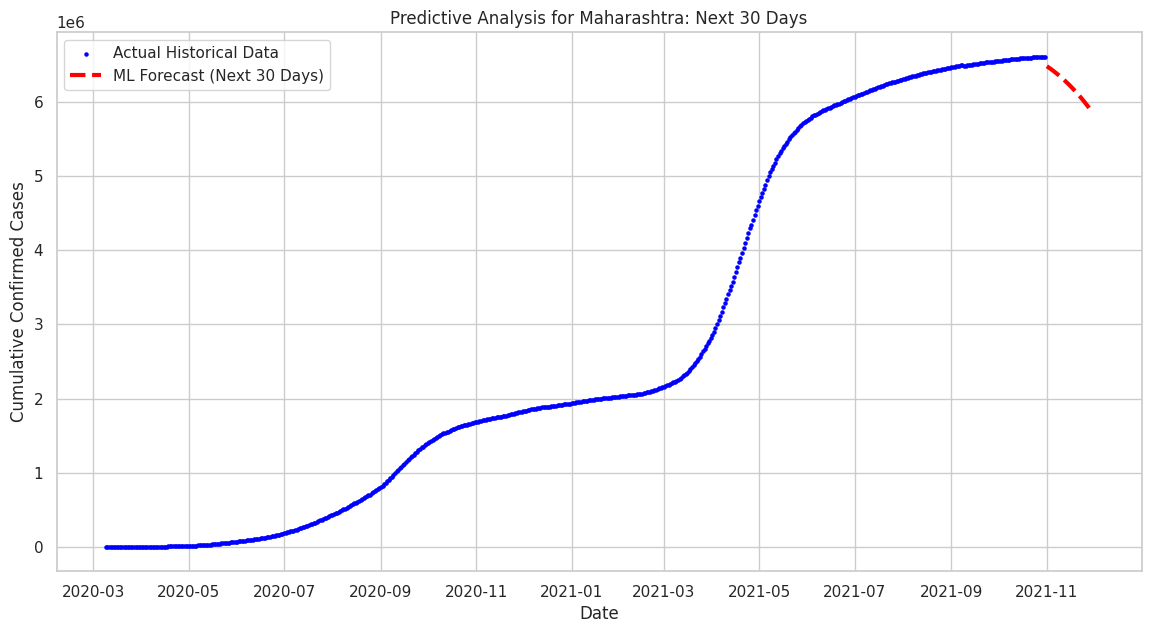

DECISION INSIGHT: The trend in Maharashtra is stabilizing. Recommendation: RELAX RESTRICTIONS.


In [8]:
import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 1. Prepare Data for ML (Using the specific state data)
# Create a 'Day Count' feature
state_df['Day_Count'] = (state_df['Date'] - state_df['Date'].min()).dt.days

X = state_df[['Day_Count']]
y = state_df['Confirmed']

# 2. Train Model (Polynomial Regression Degree 4 for complex waves)
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

# 3. Forecast Next 30 Days
last_day = state_df['Day_Count'].max()
future_days = np.array([[last_day + i] for i in range(1, 31)])
future_days_poly = poly.transform(future_days)
future_predictions = model.predict(future_days_poly)

# 4. Visualization (Actual vs Forecast)
plt.figure(figsize=(14, 7))
plt.scatter(state_df['Date'], y, color='blue', s=5, label='Actual Historical Data')

# Create date objects for future plotting
future_dates = [latest_date + datetime.timedelta(days=i) for i in range(1, 31)]
plt.plot(future_dates, future_predictions, color='red', linestyle='--', linewidth=3, label='ML Forecast (Next 30 Days)')

plt.title(f'Predictive Analysis for {target_state}: Next 30 Days')
plt.xlabel('Date')
plt.ylabel('Cumulative Confirmed Cases')
plt.legend()
plt.show()

# Decision Logic
slope = future_predictions[-1] - future_predictions[0]
if slope > 10000: # Threshold example
    print(f"DECISION INSIGHT: The model predicts a sharp rise in {target_state}. Recommendation: IMPLEMENT NIGHT CURFEW.")
else:
    print(f"DECISION INSIGHT: The trend in {target_state} is stabilizing. Recommendation: RELAX RESTRICTIONS.")

Risk Label Distribution:
Risk_Label
0    19550
1     1991
Name: count, dtype: int64
Decision Tree Accuracy: 0.92


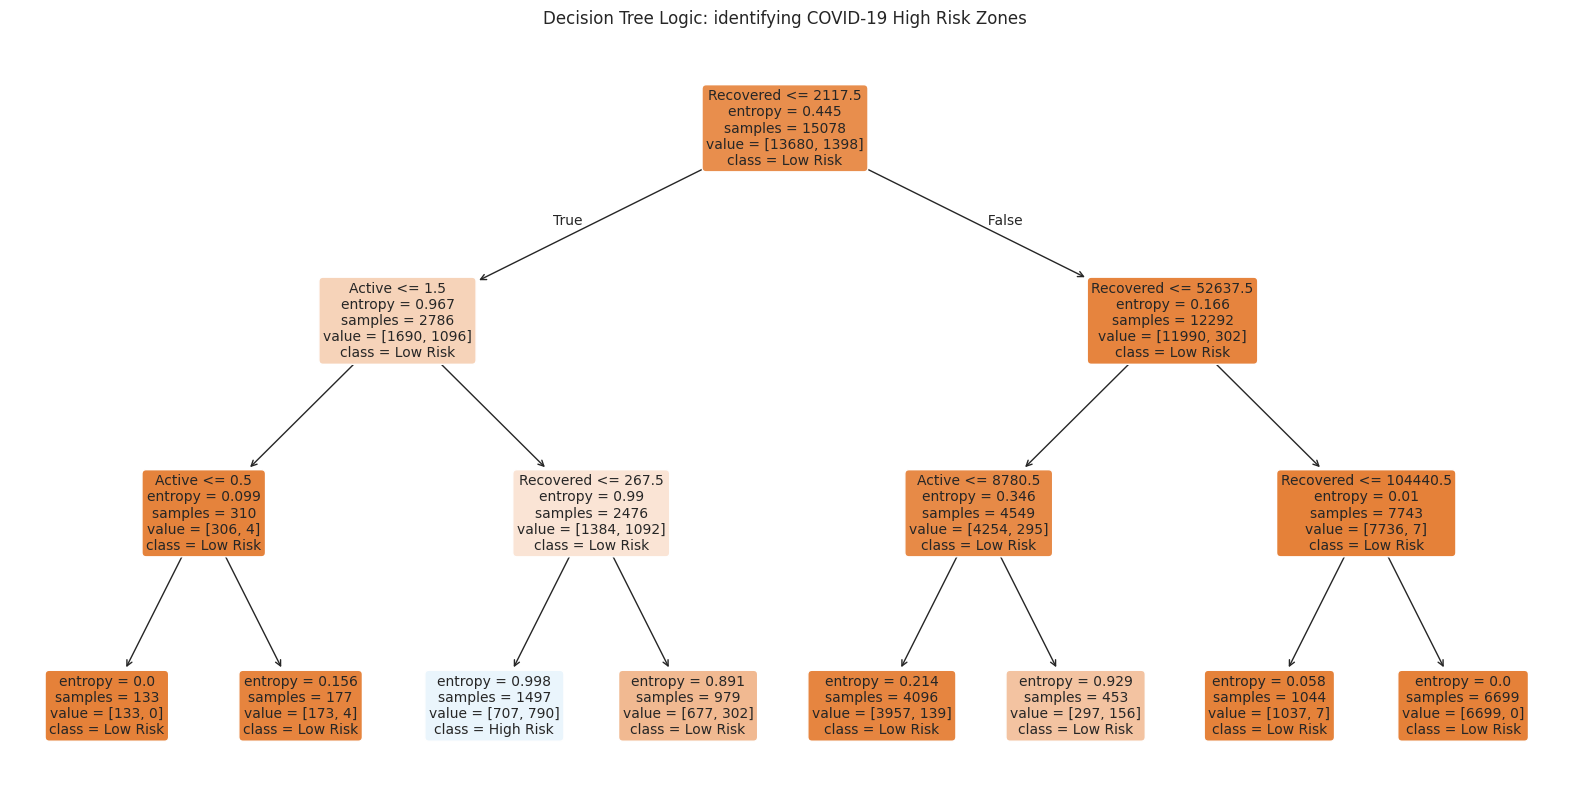

In [9]:
# Step 8: Classification with Decision Trees (Risk Assessment)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Feature Engineering for Classification
# We need to create a target variable (The "Label") for the model to learn.
# Definition: A 'High Risk' day is when Daily Cases increase by > 5% compared to yesterday.

# Calculate Daily Growth Rate
# We group by State to ensure calculations don't mix different states
df['Prev_Confirmed'] = df.groupby('State')['Confirmed'].shift(1)
df['Daily_New_Cases'] = df['Confirmed'] - df['Prev_Confirmed']
df['Growth_Rate'] = df['Daily_New_Cases'] / df['Prev_Confirmed']

# Handle NaN values created by the shift (first day has no previous day)
df.dropna(subset=['Growth_Rate'], inplace=True)

# Define Target: 1 = High Risk (Lockdown Needed), 0 = Low Risk (Open)
risk_threshold = 0.05  # 5% daily growth
df['Risk_Label'] = (df['Growth_Rate'] > risk_threshold).astype(int)

print("Risk Label Distribution:")
print(df['Risk_Label'].value_counts()) # See how many High Risk vs Low Risk days we have

# 2. Select Features (The inputs for the decision)
# Can the model predict risk based on current Active cases and Deaths?
features = ['Active', 'Recovered', 'Deceased']
X = df[features]
y = df['Risk_Label']

# 3. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Initialize and Train Decision Tree
# We limit max_depth=3 so the tree is easy to visualize and explain
tree_model = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)
tree_model.fit(X_train, y_train)

# 5. Evaluate Performance
y_pred = tree_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy:.2f}")

# 6. Visualize the Decision Logic
plt.figure(figsize=(20, 10))
plot_tree(tree_model,
          feature_names=features,
          class_names=['Low Risk', 'High Risk'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Logic: identifying COVID-19 High Risk Zones')
plt.show()